### SIAC Filtering in the Detector Variable Before FBP

This notebook verifies the use of the SIAC kernel as a filter in the detector variable prior to filtered backprojection. The purpose is to study how SIAC-based preprocessing of projection data affects the final reconstruction.

The notebook is used to test parameter configurations, inspect numerical behavior, and identify stable and meaningful parameter ranges for the Monte Carlo study.

In [6]:
import numpy as np
import pandas as pd
import odl
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [7]:
from src.siac_fourier import apply_siac_fft_nd

from src.tomo import(
    make_space_2d, 
    shepp_logan_2d, 
    parallel_geom_2d, 
    ray_transform_2d, 
    reconstruct_fbp, 
    add_relative_gaussian_noise
)

from src.metrics import(
    rel_l2_err, 
    ssim, 
    gradient_weighted_ssim, 
    eval_metrics, 
    build_metrics_table
)

from src.plotting_helpers import (
    plot_img, 
    plot_img_zoom, 
    save_image_w_zoom
)


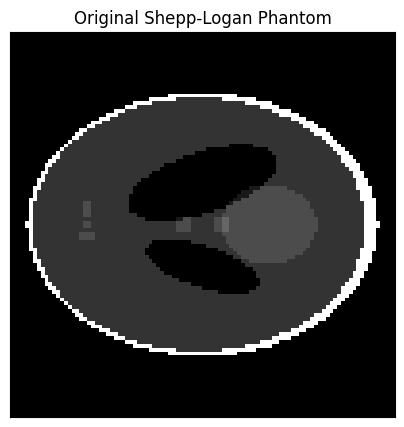

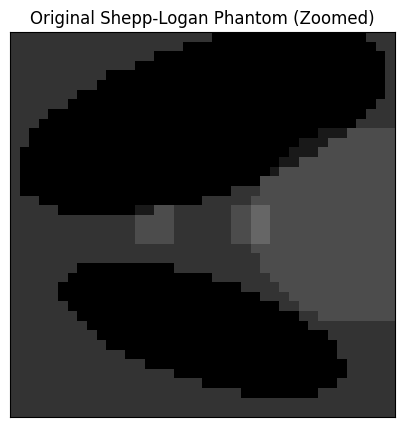

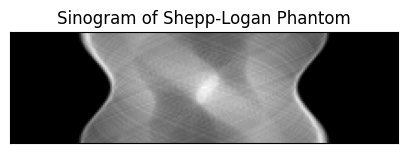

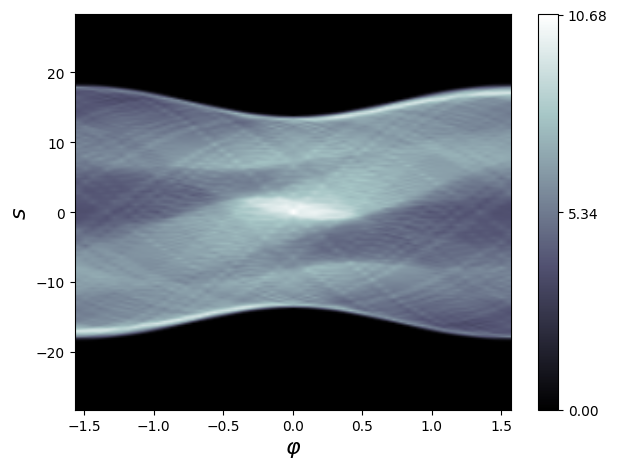

<Figure size 640x480 with 0 Axes>

In [8]:
### Create the reconstruction space and phantom ###

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 100, 100

space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

# Full angular coverage (mimic CT)
angular_coverage=(-90,90)
step = 3                    # angular resolution (3 degrees per step)

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

# testing with 10% Noise here
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)

plot_img(img=phantom, title="Original Shepp-Logan Phantom")
plot_img_zoom(img=phantom, title="Original Shepp-Logan Phantom (Zoomed)")


plot_img(img=sinogram, title="Sinogram of Shepp-Logan Phantom", 
         vmin=np.min(sinogram.asarray()), vmax=np.max(sinogram.asarray())
         )
sinogram.show()
plt.show()

In [9]:
### Compute the FBP with the ramp filter only and Hann window

# Create a Noisy phantom using the FBP
filter_used = "Ram-Lak"
fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name=filter_used)
fbp_hann = reconstruct_fbp(sino_noisy, A, filter_name="Hann")

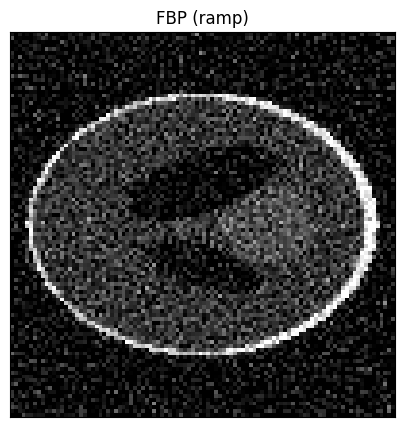

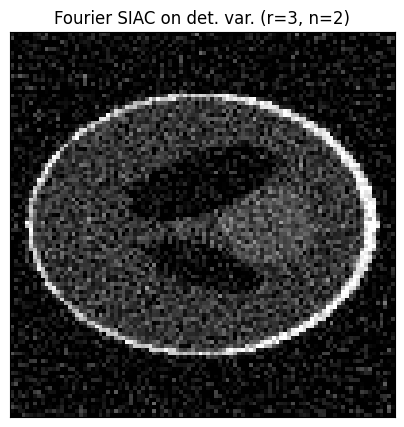

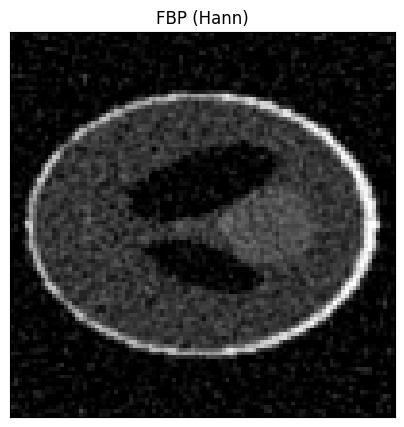

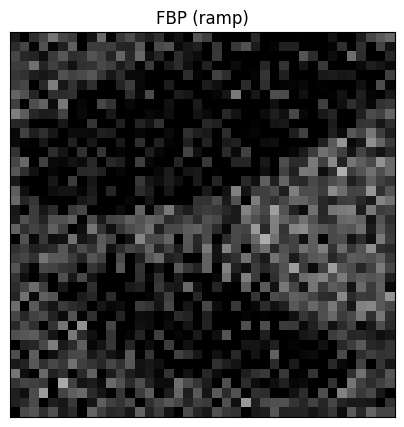

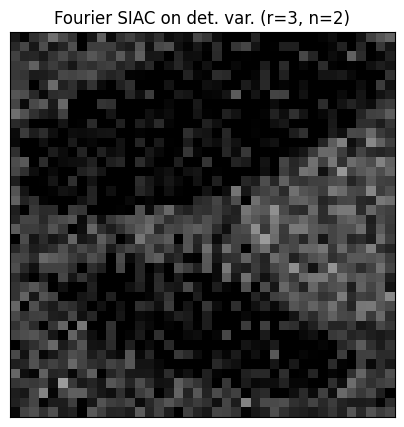

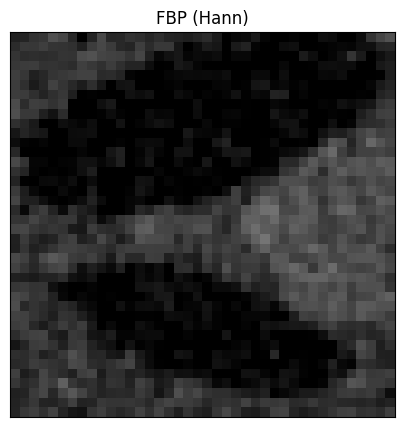

(<Figure size 500x500 with 1 Axes>, <Axes: title={'center': 'FBP (Hann)'}>)

In [10]:
dx, dy = space.cell_sides           # physical grid spacing (x, y)
d_ang, d_det = data_space.cell_sides    # (angular res (rad), detector spacing)

moments = 2
BSorder = 2

### Apply the SIAC Fourier filter in dataspace in the detector variable ###
sino_noisy_np = sino_noisy.asarray()          # (angles, detectors)
sino_np_siac = apply_siac_fft_nd(arr=sino_noisy_np, 
                                 h_per_axis = d_det, 
                                 axes=(1,),              # when moving from odl element to array, axis swap (det, ang) --> (det, ang). or more specifically, axis convention is reversed for numpy/python vs ODL
                                 moments=moments, 
                                 BSorder=BSorder, 
                                 pad_mode="reflect"
                                 )

### Backproject the filtered sinogram ###
sino_odl_siac = data_space.element(sino_np_siac)    # odl dataspace element
fbp_siac_odl = reconstruct_fbp(sino_odl_siac, A, filter_name="Ram-Lak")
fbp_siac = fbp_siac_odl.asarray()


plot_img(img=fbp_ramp, title=f"FBP (ramp)")
plot_img(img=fbp_siac, title=f"Fourier SIAC on det. var. (r={moments+1}, n={BSorder})")
plot_img(img=fbp_hann, title="FBP (Hann)")

plot_img_zoom(img=fbp_ramp, title=f"FBP (ramp)")
plot_img_zoom(img=fbp_siac, title=f"Fourier SIAC on det. var. (r={moments+1}, n={BSorder})")
plot_img_zoom(img=fbp_hann, title="FBP (Hann)")

### Testing more parameters


In [11]:
momentss = [2, 4, 6, 8, 10]
BSorders = [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20]

cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "ramp"},
    },
    "FBP-Hann": {
        "image": fbp_hann.asarray(),
        "reference": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "hann"},
    },
}

sino_noisy_np = sino_noisy.asarray()          # (angles, detectors)

for r in momentss:
    for n in BSorders:
        ### Apply the SIAC Fourier filter in dataspace in the detector variable ###
        sino_np_siac = apply_siac_fft_nd(arr=sino_noisy_np, 
                                        h_per_axis = d_det, 
                                        axes=(1,),              # when moving from odl element to array, axis swap (det, ang) --> (det, ang). or more specifically, axis convention is reversed for numpy/python vs ODL
                                        moments=r, 
                                        BSorder=n, 
                                        pad_mode="reflect"
                                        )

        ### Backproject the filtered sinogram ###
        sino_odl_siac = data_space.element(sino_np_siac)    # odl dataspace element
        fbp_siac_odl = reconstruct_fbp(sino_odl_siac, A, filter_name="Ram-Lak")
        fbp_siac = fbp_siac_odl.asarray()
        
        name = f"SIAC ODL window r{r+1} n{n}"

        cases[name] = {
            "image": fbp_siac,
            "reference": fbp_ramp.asarray(),
            "extra": {
                "method": "Fourier-SIAC-det-var",
                "filter": "ramp",
                "moments": r+1,
                "BSorder": n,
            },
        }
   
dx, dy = space.cell_sides           # physical grid spacing (x, y)
_, d_det = data_space.cell_sides    # (angular res (rad), detector spacing)
     
df = build_metrics_table(cases, truth=phantom_np, dx=dx, dy=dy, compute_reference_metrics=False)

# Since we ran a lot of experiments, we pick out the best 3 w.r.t.
# The relative L2 error, masked relative L2 error, gradient weighted SSIM, and SSIM
df_siac = df[df["method"] == "Fourier-SIAC-det-var"].copy()

best_3_l2_row = df_siac.nsmallest(3, "rel_l2_err")
best_3_masked_l2_row = df_siac.nsmallest(3, "masked_rel_l2_err")
best_3_gw_ssim = df_siac.nlargest(3, "gw_ssim")
best_3_ssim = df_siac.nlargest(3, "ssim")

df_summary = pd.concat([
    df.loc[df["name"] == "FBP-ramp"].iloc[[0]].assign(selected_as="baseline"),
    df.loc[df["name"] == "FBP-Hann"].iloc[[0]].assign(selected_as="baseline"),
    best_3_l2_row.assign(selected_as="best SIAC rel_l2"),
    best_3_masked_l2_row.assign(selected_as="best SIAC masked_rel_l2"),
    best_3_gw_ssim.assign(selected_as="best SIAC gw_ssim"),
    best_3_ssim.assign(selected_as="best SIAC ssim"),
], ignore_index=True)

cols = ["selected_as"] + [c for c in df_summary.columns if c != "selected_as"]
df_summary = df_summary[cols]

# Drop duplicates
df_summary = df_summary.drop_duplicates(subset=["name"])

df_summary

,selected_as,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error,method,filter,moments,BSorder
0,baseline,FBP-ramp,0.613357,0.290151,0.800256,0.449554,1.026095,FBP,ramp,NaN,NaN
1,baseline,FBP-Hann,0.383321,0.435581,0.829495,0.348247,0.633476,FBP,hann,NaN,NaN
2,best SIAC rel_l2,SIAC ODL window r3 n16,0.379999,0.447659,0.833845,0.347864,0.626567,Fourier-SIAC-det-var,ramp,3.0,16.0
3,best SIAC rel_l2,SIAC ODL window r3 n14,0.380120,0.434041,0.839140,0.342480,0.628840,Fourier-SIAC-det-var,ramp,3.0,14.0
4,best SIAC rel_l2,SIAC ODL window r5 n20,0.381824,0.425339,0.843205,0.339974,0.632873,Fourier-SIAC-det-var,ramp,5.0,20.0
5,best SIAC masked_rel_l2,SIAC ODL window r5 n14,0.393032,0.395687,0.849689,0.333819,0.658387,Fourier-SIAC-det-var,ramp,5.0,14.0
6,best SIAC masked_rel_l2,SIAC ODL window r5 n12,0.401238,0.384601,0.850467,0.334037,0.673866,Fourier-SIAC-det-var,ramp,5.0,12.0
7,best SIAC masked_rel_l2,SIAC ODL window r3 n8,0.399504,0.386344,0.849159,0.334253,0.668639,Fourier-SIAC-det-var,ramp,3.0,8.0
8,best SIAC gw_ssim,SIAC ODL window r7 n16,0.403364,0.382847,0.850498,0.334721,0.679082,Fourier-SIAC-det-var,ramp,7.0,16.0
10,best SIAC gw_ssim,SIAC ODL window r7 n14,0.411789,0.374321,0.850273,0.336290,0.693989,Fourier-SIAC-det-var,ramp,7.0,14.0


From the above experiments and corresponding plots, we observe that incorporating the SIAC kernel as a window function in the filtered backprojection (FBP) framework yields improved reconstruction quality when the number of reproduced moments is kept moderate, while the smoothness is increased.

In particular, choosing a moderate reproduction order ($r \approx \text{3--7}$) combined with a relatively high B-spline order ($n \approx \text{8--20}$) appears to provide balance between accuracy and stability.

This behavior can be explained by the competing roles of the SIAC parameters: increasing $r$ enhances polynomial reproduction and thus accuracy in smooth regions, but may introduce oscillatory behavior and amplify high-frequency noise when used directly in Fourier space. On the other hand, increasing $n$ improves smoothness and localization of the filter, effectively acting as a regularization mechanism that suppresses noise and stabilizes the inversion.

Hence, in the context of Fourier-domain SIAC filtering within FBP, prioritizing smoothness over exact polynomial reproduction leads to more robust and visually improved reconstructions.

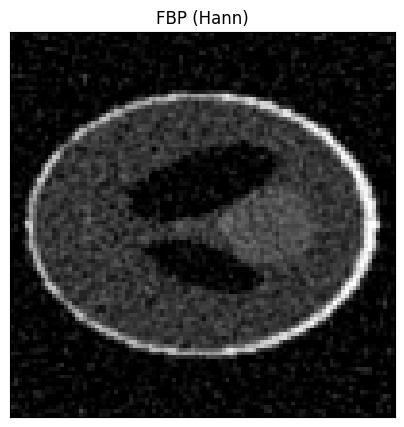

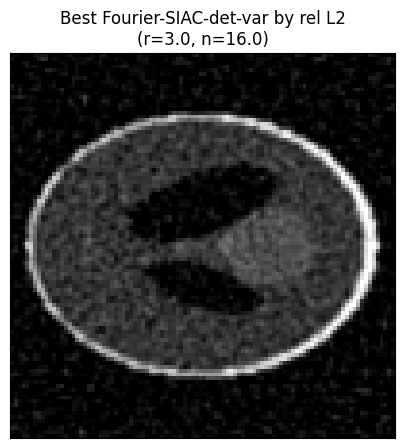

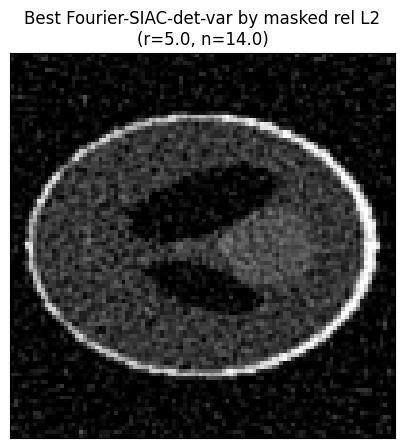

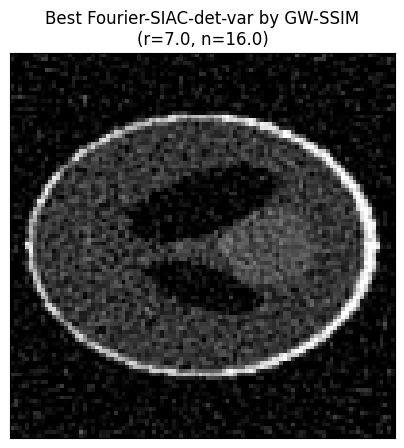

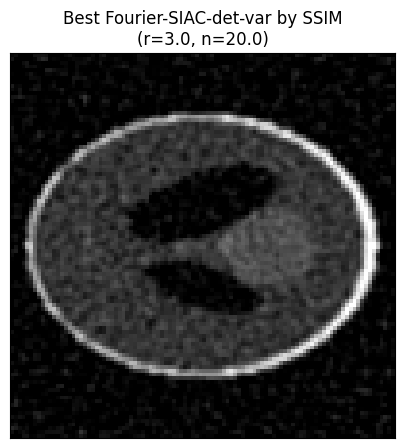

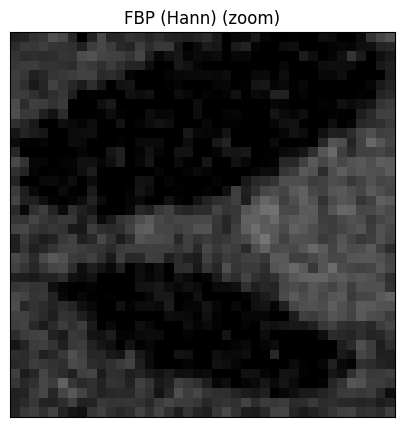

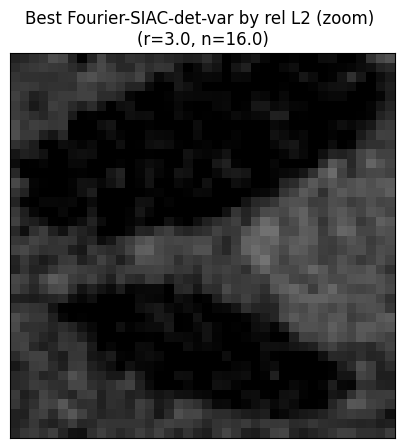

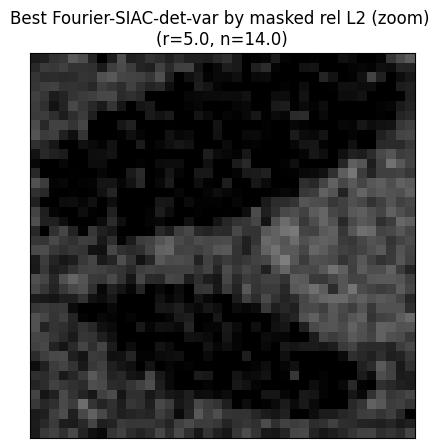

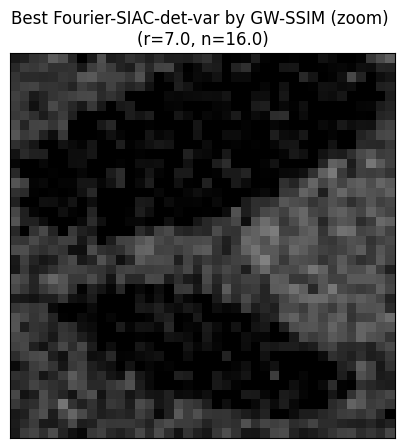

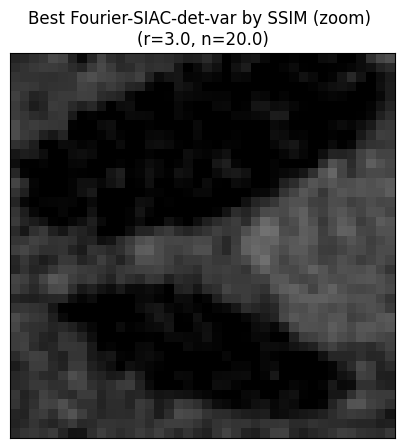

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Best Fourier-SIAC-det-var by SSIM (zoom) \n(r=3.0, n=20.0)'}>)

In [12]:
### plot the best of each metric (no duplicates) ###
df_siac2 = df_summary[df_summary["method"] == "Fourier-SIAC-det-var"].copy()

best_l2_row = df_siac2.loc[df_siac2["rel_l2_err"].idxmin()]
best_masked_l2_row = df_siac2.loc[df_siac2["masked_rel_l2_err"].idxmin()]
best_gw_ssim_row = df_siac2.loc[df_siac2["gw_ssim"].idxmax()]
best_ssim_row = df_siac2.loc[df_siac2["ssim"].idxmax()]

best_l2_name = best_l2_row["name"]
best_masked_l2_name = best_masked_l2_row["name"]
best_gwssim_name = best_gw_ssim_row["name"]
best_ssim_name = best_ssim_row["name"]

img_best_l2 = cases[best_l2_name]["image"]
img_best_masked_l2 = cases[best_masked_l2_name]["image"]
img_best_gwssim = cases[best_gwssim_name]["image"]
img_best_ssim = cases[best_ssim_name]["image"]

plot_img(img=fbp_hann, title="FBP (Hann)")
plot_img(
    img=img_best_l2,
    title=f"Best Fourier-SIAC-det-var by rel L2\n(r={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img(
    img=img_best_masked_l2,
    title=f"Best Fourier-SIAC-det-var by masked rel L2\n(r={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img(
    img=img_best_gwssim,
    title=f"Best Fourier-SIAC-det-var by GW-SSIM\n(r={best_gw_ssim_row['moments']}, n={best_gw_ssim_row['BSorder']})"
)
plot_img(
    img=img_best_ssim,
    title=f"Best Fourier-SIAC-det-var by SSIM\n(r={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

plot_img_zoom(img=fbp_hann, title="FBP (Hann) (zoom)")
plot_img_zoom(
    img=img_best_l2,
    title=f"Best Fourier-SIAC-det-var by rel L2 (zoom) \n(r={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_masked_l2,
    title=f"Best Fourier-SIAC-det-var by masked rel L2 (zoom) \n(r={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_gwssim,
    title=f"Best Fourier-SIAC-det-var by GW-SSIM (zoom) \n(r={best_gw_ssim_row['moments']}, n={best_gw_ssim_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_ssim,
    title=f"Best Fourier-SIAC-det-var by SSIM (zoom) \n(r={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)